In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv('train L.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [6]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [7]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

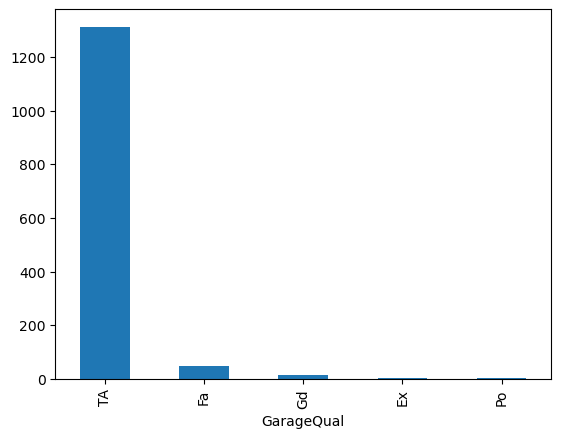

In [9]:
df['GarageQual'].value_counts().plot(kind='bar')

In [10]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'House_price')

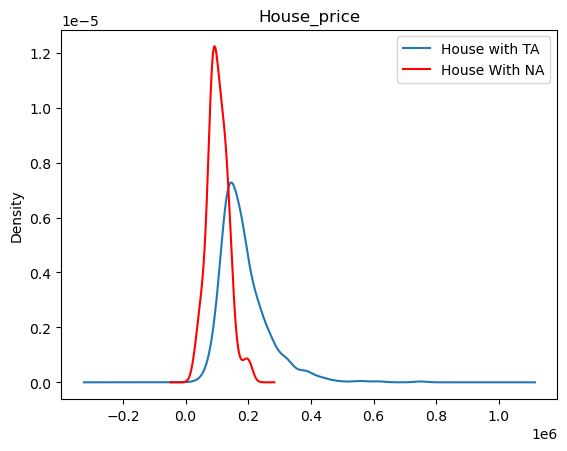

In [17]:
fig=plt.figure()
ax=fig.add_subplot(111)
# distribution of the variable after imputation
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels= ax.get_legend_handles_labels()
labels=['House with TA','House With NA']
ax.legend(lines,labels,loc='best')

plt.title('House_price')

In [19]:
temp=df[df['GarageQual']=='TA']['SalePrice']

In [21]:
df['GarageQual'].fillna('TA')

0       TA
1       TA
2       TA
3       TA
4       TA
        ..
1455    TA
1456    TA
1457    TA
1458    TA
1459    TA
Name: GarageQual, Length: 1460, dtype: object

<Axes: xlabel='GarageQual'>

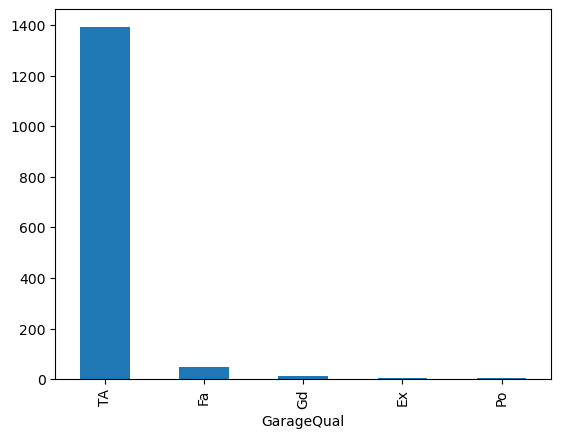

In [22]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

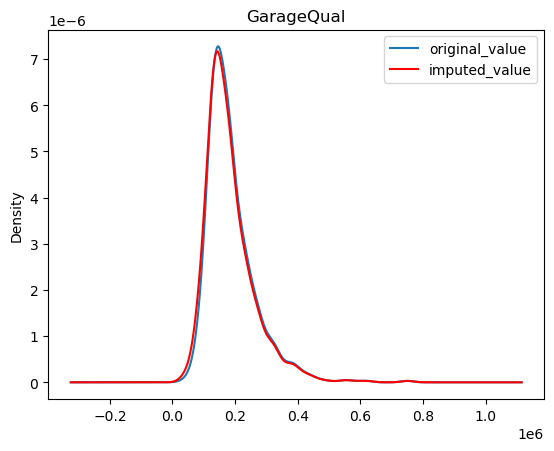

In [27]:
fig=plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)
# distribution of the variable after imputation
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['original_value','imputed_value']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

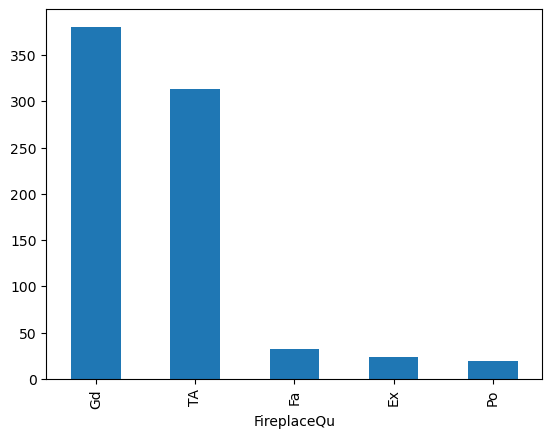

In [28]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [29]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'House ')

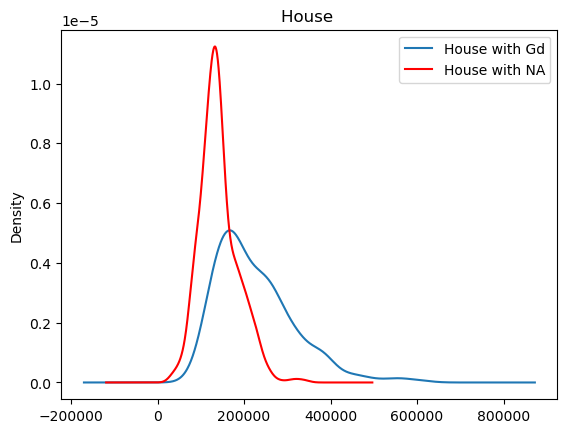

In [32]:
fig=plt.figure()
ax=fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,legend=ax.get_legend_handles_labels()
labels=['House with Gd','House with NA']
ax.legend(lines,labels,loc='best')

plt.title('House ')

In [44]:
df[df['FireplaceQu']=='Gd']['SalePrice']

0       208500
3       140000
5       143000
6       307000
10      129500
         ...  
1453     84500
1454    185000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1070, dtype: int64

In [45]:
df['FireplaceQu'].fillna('Gd')

0       Gd
1       TA
2       TA
3       Gd
4       TA
        ..
1455    TA
1456    TA
1457    Gd
1458    Gd
1459    Gd
Name: FireplaceQu, Length: 1460, dtype: object

<Axes: xlabel='FireplaceQu'>

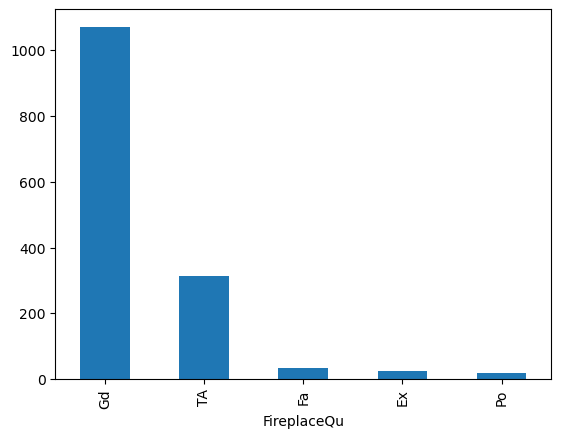

In [46]:
df['FireplaceQu'].value_counts().plot(kind='bar')

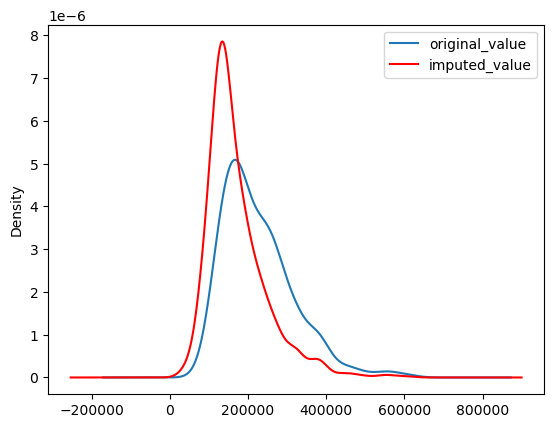

In [51]:
fig=plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,legend=ax.get_legend_handles_labels()
labels=['original_value','imputed_value']
ax.legend(lines,labels,loc='best')


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [58]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [61]:
imputer=SimpleImputer(strategy='most_frequent')

In [63]:
X_train=imputer.fit_transform(X_train)
X_test=imputer.transform(X_test)

In [64]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)